# ResNet18 RAF-DB Emotion Recognition - Kaggle Version

This notebook is prepared for Kaggle. Add the RAF-DB dataset to the notebook input, enable GPU, then run all cells. The code automatically searches `/kaggle/input` for a dataset folder that contains `train` and `test` subfolders.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import csv
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

try:
    from tqdm.auto import tqdm
except ImportError:
    class _SimpleProgress:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, **kwargs):
            pass
    def tqdm(iterable, **kwargs):
        return _SimpleProgress(iterable, **kwargs)

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-4
USE_CLAHE = True
NUM_WORKERS = 2
USE_PRETRAINED = True

# RAF-DB official labels: 1 Surprise, 2 Fear, 3 Disgust, 4 Happy, 5 Sad, 6 Angry, 7 Neutral.
# The model uses zero-based indices, so CSV label 1 becomes index 0, etc.
CLASSES = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Angry", "Neutral"]
RAF_LABEL_TO_CLASS = {i + 1: class_name for i, class_name in enumerate(CLASSES)}
CLASS_FOLDER_NAMES = {
    "Surprise": ["1", "Surprise", "surprise", "Surprised", "surprised"],
    "Fear": ["2", "Fear", "fear", "fearful", "Fearful"],
    "Disgust": ["3", "Disgust", "disgust", "disgusted", "Disgusted"],
    "Happy": ["4", "Happy", "happy", "happiness", "Happiness"],
    "Sad": ["5", "Sad", "sad", "sadness", "Sadness"],
    "Angry": ["6", "Angry", "angry", "anger", "Anger"],
    "Neutral": ["7", "Neutral", "neutral"],
}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".pgm"}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

WORKING_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
MODEL_DIR = WORKING_DIR / "models"
RESULT_DIR = WORKING_DIR / "results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print("Working dir:", WORKING_DIR)

Using device: cuda
GPU: Tesla T4
Working dir: /kaggle/working


## 2. Locate Kaggle Dataset

If auto-detection fails, set `DATASET_DIR` manually to the folder that directly contains `train` and `test`.

In [2]:
def has_train_test(path):
    path = Path(path)
    return (path / "train").is_dir() and (path / "test").is_dir()

def find_dataset_dir():
    candidates = [
        Path("/kaggle/input/raf-db-dataset/DATASET"),
        Path("/kaggle/input/raf-db-dataset/DATASET1"),
        Path("/kaggle/input/raf-db-dataset/archive"),
        Path("/kaggle/input/raf-db-dataset"),
        Path("/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"),
        Path("/kaggle/input/datasets/shuvoalok/raf-db-dataset"),
        Path.cwd() / "DATASET",
        Path.cwd() / "DATASET1",
        Path.cwd() / "archive",
    ]

    for candidate in candidates:
        if has_train_test(candidate):
            return candidate

    input_root = Path("/kaggle/input")
    if input_root.exists():
        for candidate in input_root.rglob("*"):
            if candidate.is_dir() and has_train_test(candidate):
                return candidate

    raise FileNotFoundError(
        "Could not find a dataset directory containing train/ and test/. "
        "On Kaggle, add the RAF-DB dataset as notebook input, then rerun this cell."
    )

DATASET_DIR = find_dataset_dir()
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

print("Dataset dir:", DATASET_DIR)
print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)
print("Train folders:", sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]))
print("Test folders:", sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()]))
print("Train CSV in dataset dir:", (DATASET_DIR / "train_labels.csv").exists())
print("Test CSV in dataset dir:", (DATASET_DIR / "test_labels.csv").exists())
print("Train CSV in parent dir:", (DATASET_DIR.parent / "train_labels.csv").exists())
print("Test CSV in parent dir:", (DATASET_DIR.parent / "test_labels.csv").exists())

Dataset dir: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET
Train dir: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
Test dir: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test
Train folders: ['1', '2', '3', '4', '5', '6', '7']
Test folders: ['1', '2', '3', '4', '5', '6', '7']
Train CSV in dataset dir: False
Test CSV in dataset dir: False
Train CSV in parent dir: True
Test CSV in parent dir: True


## 3. Collect Image Paths

In [3]:
def find_class_dir(split_dir, class_name):
    for folder_name in CLASS_FOLDER_NAMES[class_name]:
        class_dir = split_dir / folder_name
        if class_dir.exists():
            return class_dir
    return split_dir / class_name

def normalize_csv_label(raw_label):
    label_value = int(raw_label)
    if 1 <= label_value <= len(CLASSES):
        return label_value - 1, label_value
    if 0 <= label_value < len(CLASSES):
        return label_value, label_value + 1
    raise ValueError(f"Unexpected label value: {raw_label}")

def resolve_image_path(split_dir, image_name, raf_label):
    candidates = [
        split_dir / str(raf_label) / image_name,
        split_dir / image_name,
        split_dir / RAF_LABEL_TO_CLASS[raf_label] / image_name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    matches = list(split_dir.rglob(image_name))
    if matches:
        return matches[0]

    return candidates[0]

def collect_image_paths_from_csv(split_dir, csv_path):
    image_paths = []
    labels = []
    missing = []

    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            image_name = row.get("image") or row.get("Image") or row.get("filename") or row.get("file")
            raw_label = row.get("label") or row.get("Label") or row.get("emotion")
            if image_name is None or raw_label is None:
                raise ValueError(f"CSV must contain image and label columns. Found: {reader.fieldnames}")

            label_index, raf_label = normalize_csv_label(raw_label)
            image_path = resolve_image_path(split_dir, image_name, raf_label)

            if image_path.exists():
                image_paths.append(str(image_path))
                labels.append(label_index)
            else:
                missing.append(str(image_path))

    counts = np.bincount(np.array(labels, dtype=np.int64), minlength=len(CLASSES)) if labels else np.zeros(len(CLASSES), dtype=np.int64)
    print(f"Loaded {len(image_paths)} images from {csv_path.name}")
    for i, class_name in enumerate(CLASSES):
        print(f"  label {i + 1} {class_name}: {int(counts[i])} files")

    if missing:
        print(f"Warning: {len(missing)} CSV rows point to missing images. First missing path:", missing[0])

    return np.array(image_paths), np.array(labels, dtype=np.int64)

def find_label_csv(split_name):
    csv_name = f"{split_name}_labels.csv"
    candidates = [
        DATASET_DIR / csv_name,
        DATASET_DIR.parent / csv_name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    input_root = Path("/kaggle/input")
    if input_root.exists():
        matches = list(input_root.rglob(csv_name))
        if matches:
            return matches[0]

    return None

def collect_image_paths_from_folders(split_dir):
    image_paths = []
    labels = []

    for label_index, class_name in enumerate(CLASSES):
        class_dir = find_class_dir(split_dir, class_name)
        if not class_dir.exists():
            print("Missing folder:", class_dir)
            continue

        files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])
        print(f"{split_dir.name}/{class_name}: {len(files)} files")

        for file_path in files:
            image_paths.append(str(file_path))
            labels.append(label_index)

    return np.array(image_paths), np.array(labels, dtype=np.int64)

def collect_image_paths(split_dir, split_name):
    csv_path = find_label_csv(split_name)
    if csv_path is not None:
        print(f"Using label CSV for {split_name}:", csv_path)
        return collect_image_paths_from_csv(split_dir, csv_path)

    print(f"{split_name}_labels.csv not found; falling back to folder-name labels.")
    return collect_image_paths_from_folders(split_dir)

train_all_paths, train_all_labels = collect_image_paths(TRAIN_DIR, "train")
test_paths, test_labels = collect_image_paths(TEST_DIR, "test")

print("Total train/val images:", len(train_all_paths))
print("Total test images:", len(test_paths))

if len(train_all_paths) == 0 or len(test_paths) == 0:
    raise RuntimeError("No images found. Please check DATASET_DIR, CSV files, and image folders.")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_all_paths,
    train_all_labels,
    test_size=0.15,
    random_state=SEED,
    stratify=train_all_labels,
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))


Using label CSV for train: /kaggle/input/datasets/shuvoalok/raf-db-dataset/train_labels.csv
Loaded 12271 images from train_labels.csv
  label 1 Surprise: 1290 files
  label 2 Fear: 281 files
  label 3 Disgust: 717 files
  label 4 Happy: 4772 files
  label 5 Sad: 1982 files
  label 6 Angry: 705 files
  label 7 Neutral: 2524 files
Using label CSV for test: /kaggle/input/datasets/shuvoalok/raf-db-dataset/test_labels.csv
Loaded 3068 images from test_labels.csv
  label 1 Surprise: 329 files
  label 2 Fear: 74 files
  label 3 Disgust: 160 files
  label 4 Happy: 1185 files
  label 5 Sad: 478 files
  label 6 Angry: 162 files
  label 7 Neutral: 680 files
Total train/val images: 12271
Total test images: 3068
Train: 10430
Validation: 1841
Test: 3068


## 4. Dataset and DataLoaders

In [4]:
def apply_clahe(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_img)

class ResNetEmotionDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, use_clahe=True):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = int(self.labels[index])

        gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            gray = np.zeros((48, 48), dtype=np.uint8)

        if self.use_clahe:
            gray = apply_clahe(gray)

        rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        image = self.transform(rgb) if self.transform is not None else torch.tensor(rgb).permute(2, 0, 1).float() / 255.0
        return image, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ResNetEmotionDataset(train_paths, train_labels, train_transform, use_clahe=USE_CLAHE)
val_dataset = ResNetEmotionDataset(val_paths, val_labels, eval_transform, use_clahe=USE_CLAHE)
test_dataset = ResNetEmotionDataset(test_paths, test_labels, eval_transform, use_clahe=USE_CLAHE)

pin_memory = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

Batch image shape: torch.Size([64, 3, 224, 224])
Batch labels shape: torch.Size([64])


## 5. Preview Samples

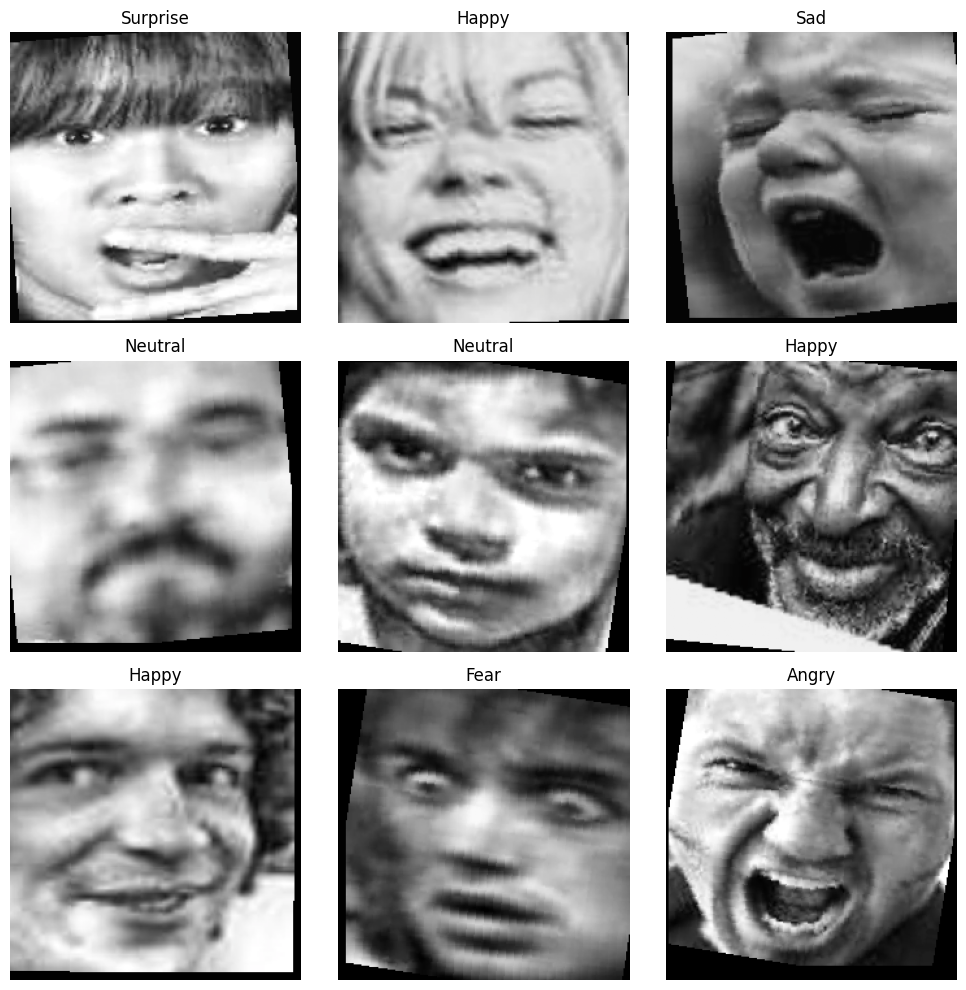

In [5]:
def unnormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = tensor.cpu() * std + mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image

plt.figure(figsize=(10, 10))
for i in range(min(9, images.size(0))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(unnormalize_image(images[i]))
    plt.title(CLASSES[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Build ResNet18 Model

When internet is enabled, this tries to use ImageNet pretrained weights. If downloading is unavailable, it falls back to random initialization.

In [6]:
def build_resnet18(num_classes):
    if USE_PRETRAINED:
        try:
            weights = models.ResNet18_Weights.DEFAULT
            model = models.resnet18(weights=weights)
            print("Loaded ImageNet pretrained ResNet18 weights")
            used_pretrained = True
        except Exception as exc:
            print("Could not load pretrained weights. Falling back to random initialization.")
            print("Reason:", exc)
            model = models.resnet18(weights=None)
            used_pretrained = False
    else:
        model = models.resnet18(weights=None)
        used_pretrained = False

    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model.to(device), used_pretrained

model, used_pretrained = build_resnet18(len(CLASSES))
print("Used pretrained:", used_pretrained)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]

Loaded ImageNet pretrained ResNet18 weights
Used pretrained: True


## 7. Training and Evaluation Functions

In [7]:
def calculate_class_weights(labels):
    counts = np.bincount(labels, minlength=len(CLASSES)).astype(np.float32)
    total = len(labels)
    raw_weights = total / (len(CLASSES) * np.maximum(counts, 1.0))
    weights = np.sqrt(raw_weights)
    weights = np.clip(weights, 0.5, 3.0)

    print("Class counts and weights:")
    for class_name, count, weight in zip(CLASSES, counts, weights):
        print(f"{class_name}: count={int(count)}, weight={weight:.4f}")

    return torch.tensor(weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=calculate_class_weights(train_labels).to(device))
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

def train_one_epoch(model, loader, epoch_index=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader, desc=f"Train {epoch_index}" if epoch_index else "Train", leave=False)
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        progress.set_postfix(loss=running_loss / max(total, 1), acc=correct / max(total, 1))

    return running_loss / total, correct / total

def evaluate(model, loader, epoch_index=None, split_name="Validation"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    progress = tqdm(loader, desc=f"{split_name} {epoch_index}" if epoch_index else split_name, leave=False)
    with torch.no_grad():
        for images, labels in progress:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            progress.set_postfix(loss=running_loss / max(total, 1), acc=correct / max(total, 1))

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return running_loss / total, correct / total, macro_f1, all_labels, all_preds

Class counts and weights:
Surprise: count=1097, weight=1.1654
Fear: count=239, weight=2.4969
Disgust: count=609, weight=1.5642
Happy: count=4056, weight=0.6061
Sad: count=1685, weight=0.9404
Angry: count=599, weight=1.5772
Neutral: count=2145, weight=0.8334


/tmp/ipykernel_23/3795575901.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


## 8. Train ResNet18

Best checkpoint selection uses validation macro F1, which is better than plain accuracy for imbalanced emotion classes.

In [ ]:
best_val_macro_f1 = 0.0
best_model_path = MODEL_DIR / "best_resnet18_emotion.pth"
final_model_path = MODEL_DIR / "final_resnet18_emotion.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_macro_f1": [],
}

start_time = time.time()
for epoch in tqdm(range(EPOCHS), desc="Epochs"):
    epoch_number = epoch + 1
    train_loss, train_acc = train_one_epoch(model, train_loader, epoch_index=epoch_number)
    val_loss, val_acc, val_macro_f1, _, _ = evaluate(model, val_loader, epoch_index=epoch_number, split_name="Validation")
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)

    print(
        f"Epoch [{epoch_number}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} "
        f"Val Macro F1: {val_macro_f1:.4f} LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "classes": CLASSES,
                "img_size": IMG_SIZE,
                "use_clahe": USE_CLAHE,
                "used_pretrained": used_pretrained,
                "best_val_macro_f1": best_val_macro_f1,
                "epoch": epoch_number,
            },
            best_model_path,
        )
        print("Best model saved:", best_model_path)

elapsed = time.time() - start_time
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "classes": CLASSES,
        "img_size": IMG_SIZE,
        "use_clahe": USE_CLAHE,
        "used_pretrained": used_pretrained,
        "final_val_macro_f1": history["val_macro_f1"][-1],
    },
    final_model_path,
)

print(f"Training finished in {elapsed / 60:.2f} minutes")
print("Best validation macro F1:", best_val_macro_f1)
print("Best model:", best_model_path)
print("Final model:", final_model_path)

## 9. Plot Training Curves

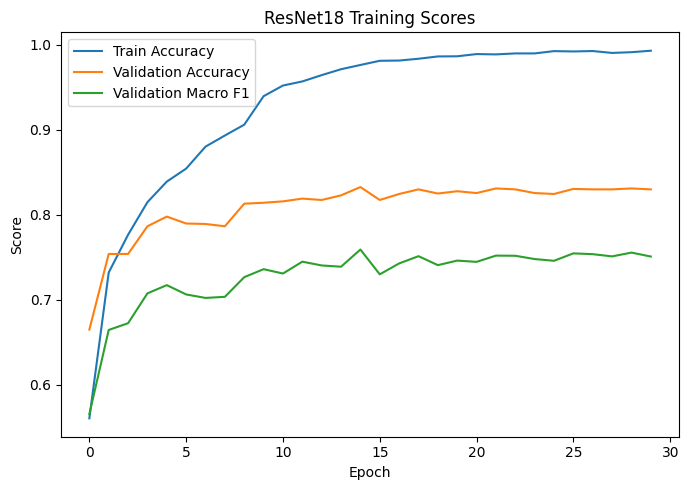

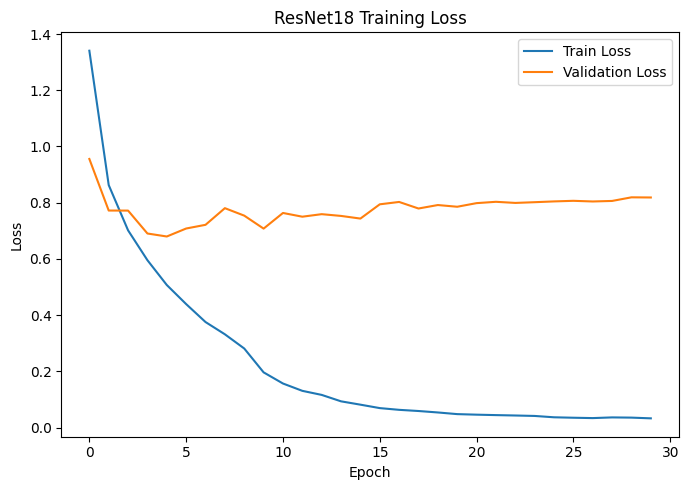

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.plot(history["val_macro_f1"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("ResNet18 Training Scores")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "resnet18_accuracy_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "resnet18_loss_curve.png", dpi=150)
plt.show()

## 10. Test Set Evaluation

Test:   0%|          | 0/48 [00:00<?, ?it/s]

/tmp/ipykernel_23/3795575901.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


Test Loss: 0.6494231202300866
Test Accuracy: 0.8301825293350718
Test Macro F1: 0.7620047791284533
              precision    recall  f1-score   support

    Surprise     0.8085    0.8723    0.8392       329
        Fear     0.7778    0.5676    0.6562        74
     Disgust     0.5460    0.5938    0.5689       160
       Happy     0.9460    0.9021    0.9235      1185
         Sad     0.7760    0.7971    0.7864       478
       Angry     0.7471    0.7840    0.7651       162
     Neutral     0.7867    0.8029    0.7948       680

    accuracy                         0.8302      3068
   macro avg     0.7697    0.7600    0.7620      3068
weighted avg     0.8340    0.8302    0.8313      3068



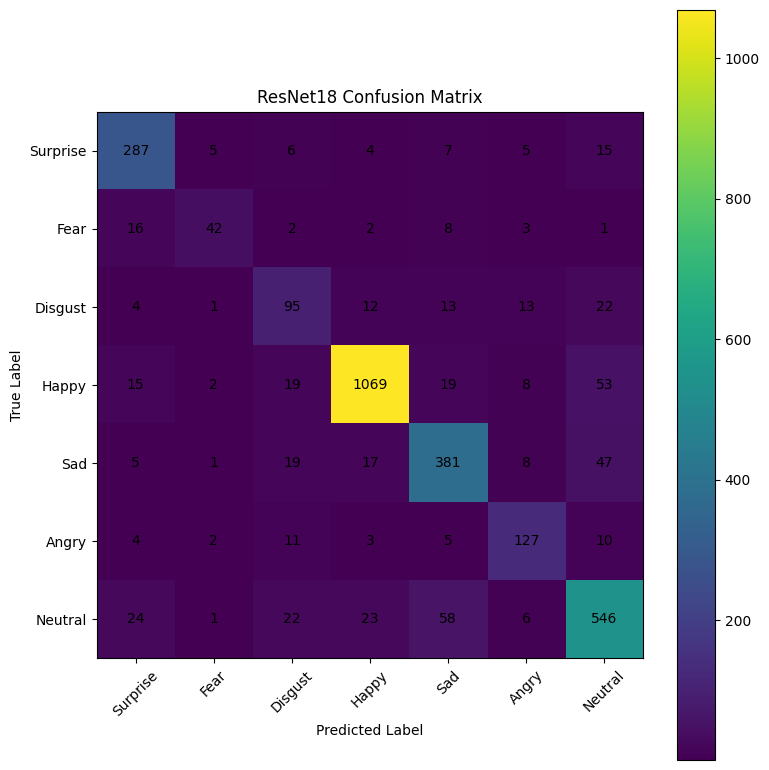

Best validation macro F1: 0.7591
Test loss: 0.6494
Test accuracy: 0.8302
Test macro F1: 0.7620
Best model: /kaggle/working/models/best_resnet18_emotion.pth
Final model: /kaggle/working/models/final_resnet18_emotion.pth

Saved outputs to: /kaggle/working/results


In [10]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loss, test_acc, test_macro_f1, true_labels, pred_labels = evaluate(model, test_loader, split_name="Test")

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Macro F1:", test_macro_f1)

report = classification_report(true_labels, pred_labels, target_names=CLASSES, zero_division=0, digits=4)
print(report)
(RESULT_DIR / "classification_report_resnet18.txt").write_text(report)

cm = confusion_matrix(true_labels, pred_labels, labels=np.arange(len(CLASSES)))
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(CLASSES)), CLASSES, rotation=45)
plt.yticks(np.arange(len(CLASSES)), CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.savefig(RESULT_DIR / "confusion_matrix_resnet18.png", dpi=150)
plt.show()

summary = (
    f"Best validation macro F1: {checkpoint.get('best_val_macro_f1', float('nan')):.4f}\n"
    f"Test loss: {test_loss:.4f}\n"
    f"Test accuracy: {test_acc:.4f}\n"
    f"Test macro F1: {test_macro_f1:.4f}\n"
    f"Best model: {best_model_path}\n"
    f"Final model: {final_model_path}\n"
)
(RESULT_DIR / "resnet18_summary.txt").write_text(summary)
print(summary)
print("Saved outputs to:", RESULT_DIR)


## 11. Single Image Prediction

Sample image: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2941_aligned.jpg


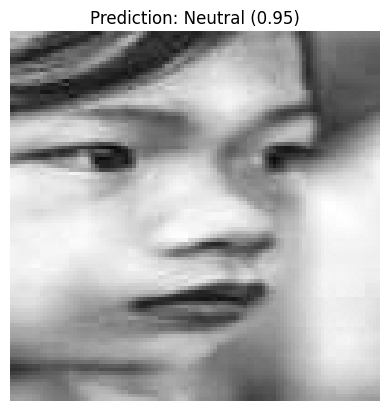

Surprise: 0.0395
Fear: 0.0000
Disgust: 0.0039
Happy: 0.0006
Sad: 0.0002
Angry: 0.0018
Neutral: 0.9540


In [11]:
def predict_emotion_image(image_path):
    checkpoint = torch.load(best_model_path, map_location=device)
    classes = checkpoint.get("classes", CLASSES)
    img_size = checkpoint.get("img_size", IMG_SIZE)
    use_clahe = checkpoint.get("use_clahe", USE_CLAHE)

    inference_model = models.resnet18(weights=None)
    inference_model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(inference_model.fc.in_features, len(classes)),
    )
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.to(device)
    inference_model.eval()

    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Could not read image: {image_path}")
    if use_clahe:
        gray = apply_clahe(gray)
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    tensor = eval_transform(rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = inference_model(tensor)
        probs = torch.softmax(logits, dim=1)[0]
        confidence, index = torch.max(probs, dim=0)

    plt.imshow(rgb)
    plt.title(f"Prediction: {classes[index.item()]} ({confidence.item():.2f})")
    plt.axis("off")
    plt.show()

    for class_name, prob in zip(classes, probs.cpu().numpy()):
        print(f"{class_name}: {prob:.4f}")

    return classes[index.item()], confidence.item()

sample_img_path = next(TEST_DIR.rglob("*.jpg"), None)
if sample_img_path is None:
    sample_img_path = next(TEST_DIR.rglob("*.png"), None)
print("Sample image:", sample_img_path)
if sample_img_path is not None:
    predict_emotion_image(sample_img_path)